# ParkPing Zone Predictor

## 1. Import libraries & read the CSV

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./data/IIoT_Smart_Parking_Management.csv")
print(df.shape)
df.head()

(1000, 28)


,Timestamp,Parking_Spot_ID,Sensor_Reading_Proximity,Sensor_Reading_Pressure,Vehicle_Type_Weight,Vehicle_Type_Height,User_Type,Weather_Temperature,Weather_Precipitation,Nearby_Traffic_Level,...,Occupancy_Status,Vehicle_Type,Parking_Violation,Sensor_Reading_Ultrasonic,Parking_Duration,Environmental_Noise_Level,Dynamic_Pricing_Factor,Spot_Size,Proximity_To_Exit,User_Parking_History
0,2021-01-01 00:00:00.000000000,20,1.023651,1.541461,1831.770127,4.392528,Visitor,18.092553,1,Low,...,Occupied,Car,0,102.951052,4,55.620740,0.8,Standard,6.610474,6.660310
1,2021-01-02 06:39:16.756756756,49,3.903349,1.621719,1330.815754,4.595638,Registered,13.397533,0,Low,...,Occupied,Car,0,87.559131,3,56.682386,1.2,Compact,8.678719,6.766187
2,2021-01-03 13:18:33.513513513,38,10.315709,6.292374,1255.134827,4.313721,Registered,21.687410,0,High,...,Vacant,Car,1,100.061854,5,59.239322,0.8,Standard,13.795262,-0.910052
3,2021-01-04 19:57:50.270270270,31,6.588039,1.659870,1523.442919,3.567329,Visitor,18.683461,0,Medium,...,Vacant,Motorcycle,1,110.594598,2,44.545155,0.8,Standard,1.678721,10.415888
4,2021-01-06 02:37:07.027027027,8,8.213969,3.278467,1758.490837,5.145836,Visitor,19.214876,0,High,...,Occupied,Car,0,84.786963,2,48.012604,0.8,Standard,20.012252,4.355544


## 2. Keep only what we need

In [2]:
df = df[["Timestamp", "Parking_Spot_ID", "Parking_Lot_Section", "Occupancy_Status"]]
df.head()

,Timestamp,Parking_Spot_ID,Parking_Lot_Section,Occupancy_Status
0,2021-01-01 00:00:00.000000000,20,Zone A,Occupied
1,2021-01-02 06:39:16.756756756,49,Zone A,Occupied
2,2021-01-03 13:18:33.513513513,38,Zone B,Vacant
3,2021-01-04 19:57:50.270270270,31,Zone B,Vacant
4,2021-01-06 02:37:07.027027027,8,Zone C,Occupied


## 3. Check if the data is healthy, along with the min & max

In [3]:
print("empty cells:", df.isnull().sum().sum())
print("copied rows:", df.duplicated().sum())
print("smallest spot ID:", df["Parking_Spot_ID"].min())
print("biggest spot ID:", df["Parking_Spot_ID"].max())

empty cells: 0
copied rows: 0
smallest spot ID: 1
biggest spot ID: 50


In [4]:
print(df["Parking_Lot_Section"].value_counts())
print(df.groupby("Parking_Lot_Section")["Parking_Spot_ID"].nunique()) #Count different IDs once, ignoring repeats
print(df["Occupancy_Status"].value_counts())

Parking_Lot_Section
Zone A    382
Zone B    307
Zone C    197
Zone D    114
Name: count, dtype: int64
Parking_Lot_Section
Zone A    50
Zone B    50
Zone C    49
Zone D    44
Name: Parking_Spot_ID, dtype: int64
Occupancy_Status
Occupied    550
Vacant      450
Name: count, dtype: int64


## 4. Make the three clues and the answer

In [5]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day_name()
df["Occupied"] = df["Occupancy_Status"].map({"Occupied": 1, "Vacant": 0}) #representing it to numerical 
df.head()

,Timestamp,Parking_Spot_ID,Parking_Lot_Section,Occupancy_Status,Hour,Day,Occupied
0,2021-01-01 00:00:00.000000000,20,Zone A,Occupied,0,Friday,1
1,2021-01-02 06:39:16.756756756,49,Zone A,Occupied,6,Saturday,1
2,2021-01-03 13:18:33.513513513,38,Zone B,Vacant,13,Sunday,0
3,2021-01-04 19:57:50.270270270,31,Zone B,Vacant,19,Monday,0
4,2021-01-06 02:37:07.027027027,8,Zone C,Occupied,2,Wednesday,1


## 5. Look at the patterns

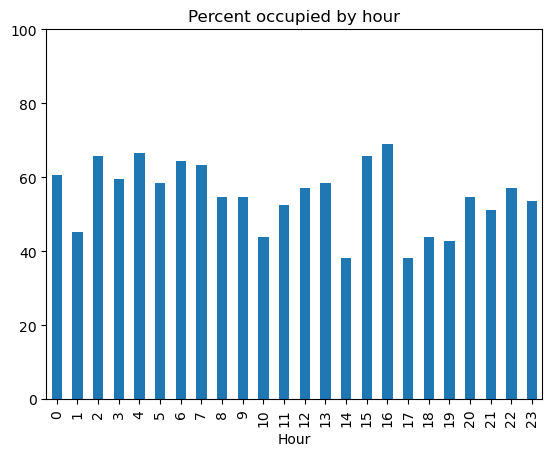

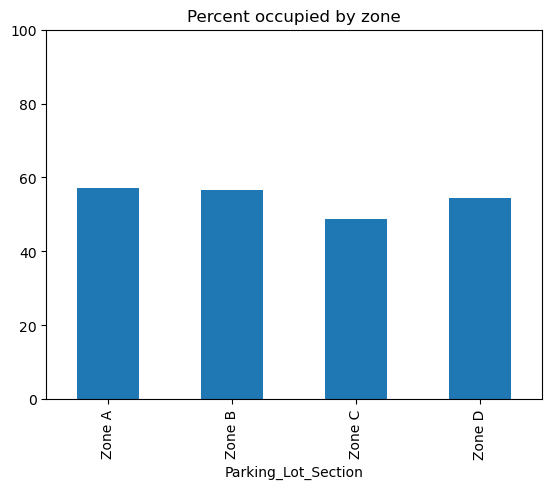

In [6]:
(df.groupby("Hour")["Occupied"].mean() * 100).plot(kind="bar", title="Percent occupied by hour") #get records by hour inside occupied column
plt.ylim(0, 100)
plt.show()

(df.groupby("Parking_Lot_Section")["Occupied"].mean() * 100).plot(kind="bar", title="Percent occupied by zone")
plt.ylim(0, 100)
plt.show()

## 6. Split: old records to learn from, new records to test on

In [7]:
df = df.sort_values("Timestamp") #data sorted from oldest to newest, making predictions about later observations using earlier observations. 

features = ["Hour", "Day", "Parking_Lot_Section"] #questions
target = "Occupied" #answers

X = df[features]
y = df[target]

cut = int(len(df) * 0.8) #of 1000 rows takes 80% converts to integer saved to cut (cut = 800)
X_train, y_train = X.iloc[:cut], y.iloc[:cut] #train 80
X_test, y_test = X.iloc[cut:], y.iloc[cut:] #test 20

print("learn rows:", len(X_train), " test rows:", len(X_test))

learn rows: 800  test rows: 200


## 7. The lazy guess (baseline)

In [8]:
from sklearn.dummy import DummyClassifier

lazy = DummyClassifier(strategy="most_frequent")
lazy.fit(X_train, y_train)
print("lazy guess score:", round(lazy.score(X_test, y_test), 3))

lazy guess score: 0.525


## 8. The real model: a decision tree

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_text

translator = ColumnTransformer(
    [("words", OneHotEncoder(handle_unknown="ignore"), ["Day", "Parking_Lot_Section"])], #turns Day & Parking Lot categories into sepearate numeric columns.
    remainder="passthrough",
)
tree = DecisionTreeClassifier(max_depth=3, random_state=42) # Max depth of 3 decisions per branch, random states helps reproduce the same results.
model = Pipeline([("translate", translator), ("tree", tree)]) #Translate data then feed to decision tree after.

model.fit(X_train, y_train) #training the model, learn patterns and fitting to correct answers.
print("tree score:", round(model.score(X_test, y_test), 3)) #print the score after training and tested.

tree score: 0.565


In [10]:
names = model.named_steps["translate"].get_feature_names_out() 
print(export_text(model.named_steps["tree"], feature_names=list(names)))

|--- remainder__Hour <= 5.50
|   |--- words__Parking_Lot_Section_Zone C <= 0.50
|   |   |--- words__Day_Saturday <= 0.50
|   |   |   |--- class: 1
|   |   |--- words__Day_Saturday >  0.50
|   |   |   |--- class: 1
|   |--- words__Parking_Lot_Section_Zone C >  0.50
|   |   |--- words__Day_Monday <= 0.50
|   |   |   |--- class: 1
|   |   |--- words__Day_Monday >  0.50
|   |   |   |--- class: 0
|--- remainder__Hour >  5.50
|   |--- words__Day_Friday <= 0.50
|   |   |--- remainder__Hour <= 16.50
|   |   |   |--- class: 1
|   |   |--- remainder__Hour >  16.50
|   |   |   |--- class: 0
|   |--- words__Day_Friday >  0.50
|   |   |--- words__Parking_Lot_Section_Zone C <= 0.50
|   |   |   |--- class: 1
|   |   |--- words__Parking_Lot_Section_Zone C >  0.50
|   |   |   |--- class: 0



This prints the questions the tree learned. Read it top to bottom like a flowchart.

- `Hour <= 5.50` means "is it before 6 am?"
- `Day_Friday <= 0.50` means "is it **not** Friday?"
- `class: 1` means it answers Occupied. `class: 0` means Vacant.

## 9. Mark the test properly (Detailed Breakdown of the results)

              precision    recall  f1-score   support

      Vacant       0.57      0.36      0.44        95
    Occupied       0.56      0.75      0.64       105

    accuracy                           0.56       200
   macro avg       0.57      0.56      0.54       200
weighted avg       0.57      0.56      0.55       200



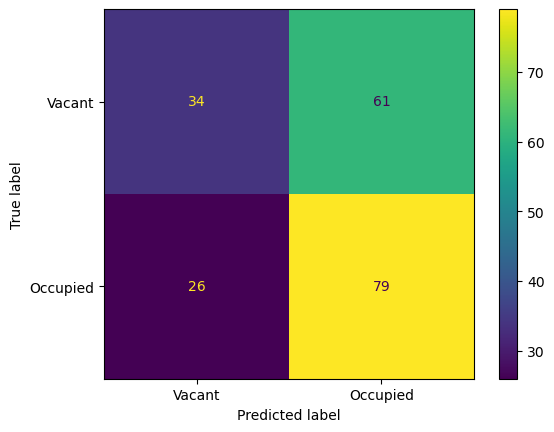

In [11]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

pred = model.predict(X_test) #predict for each row of 200
print(classification_report(y_test, pred, target_names=["Vacant", "Occupied"])) #calculate metrics, with real ans,model prediction, give readable labels

ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Vacant", "Occupied"])
plt.show()

## 10. Save the calculator, open it again, ask one question

In [12]:
import joblib

joblib.dump(model, "model/parkping_model.joblib")
loaded = joblib.load("model/parkping_model.joblib")

question = pd.DataFrame([{"Hour": 14, "Day": "Monday", "Parking_Lot_Section": "Zone A"}])
chance = loaded.predict_proba(question)[0][1]
print("Monday 14:00, Zone A:", round(chance * 100), "% chance occupied")

Monday 14:00, Zone A: 57 % chance occupied


## 11. Save the tidy table

In [13]:
df[["Timestamp", "Parking_Spot_ID", "Parking_Lot_Section", "Hour", "Day", "Occupied"]].to_csv(
    "data/final_parking_cleaned.csv", index=False
)
print("saved")

saved


The cleaned CSV contains the historical parking observations and can be used to display historical occupancy charts and statistics in ParkPing. The saved model is used to estimate occupancy for a selected day, hour and zone.